# Лабораторная работа 6. Модели линейной регрессии

### Задание 1.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import make_regression

# Настройка отображения графиков
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [3]:
np.random.seed(42)

# Генерация данных с явным указанием имен признаков
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Создаем DataFrame с правильными именами столбцов
df = pd.DataFrame(X, columns=['feature'])
df['target'] = y

print("Первые 5 строк данных:")
print(df.head())
print(f"\nРазмер данных: {df.shape}")

Первые 5 строк данных:
    feature     target
0  0.931280  50.779929
1  0.087047 -10.065270
2 -1.057711 -34.918392
3  0.314247  10.526743
4 -0.479174 -17.738377

Размер данных: (100, 2)


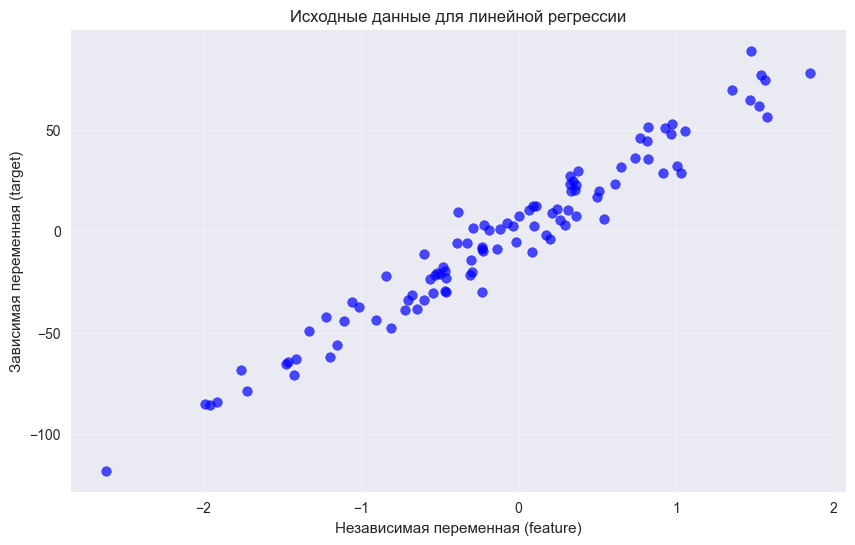

In [12]:
# Визуализация данных
plt.figure(figsize=(10, 6))
plt.scatter(df['feature'], df['target'], alpha=0.7, color='blue')
plt.title('Исходные данные для линейной регрессии')
plt.xlabel('Независимая переменная (feature)')
plt.ylabel('Зависимая переменная (target)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['feature']], df['target'], test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Имена признаков: {X_train.columns.tolist()}")

Размер обучающей выборки: 80
Размер тестовой выборки: 20
Имена признаков: ['feature']


In [5]:
# Создание и обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Вывод параметров модели
print("Параметры модели:")
print(f"Коэффициент (наклон): {model.coef_[0]:.4f}")
print(f"Свободный член (intercept): {model.intercept_:.4f}")
print(f"Имена признаков, которые запомнила модель: {model.feature_names_in_}")

Параметры модели:
Коэффициент (наклон): 44.2442
Свободный член (intercept): 0.0992
Имена признаков, которые запомнила модель: ['feature']


In [14]:
# Прогнозирование и оценка модели
y_pred = model.predict(X_test)

# Вычисление метрик качества
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Метрики качества модели:")
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE (Средняя абсолютная ошибка): {mae:.4f}")
print(f"R² (Коэффициент детерминации): {r2:.4f}")

Метрики качества модели:
MSE : 104.2022
RMSE : 10.2079
MAE (Средняя абсолютная ошибка): 8.4167
R² (Коэффициент детерминации): 0.9374


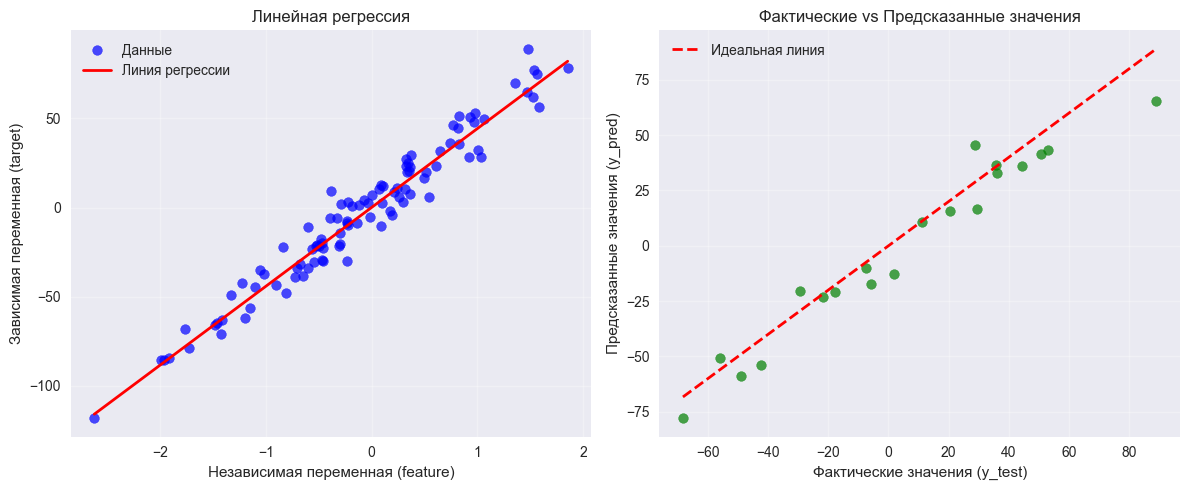

In [13]:
# Визуализация результатов
plt.figure(figsize=(12, 5))

# График 1: Исходные данные и линия регрессии
plt.subplot(1, 2, 1)
plt.scatter(df['feature'], df['target'], alpha=0.7, color='blue', label='Данные')

# Создаем DataFrame для предсказания с правильными именами признаков
x_range = np.linspace(df['feature'].min(), df['feature'].max(), 100)
x_range_df = pd.DataFrame(x_range, columns=['feature'])
y_range = model.predict(x_range_df)

plt.plot(x_range, y_range, color='red', linewidth=2, label='Линия регрессии')
plt.title('Линейная регрессия')
plt.xlabel('Независимая переменная (feature)')
plt.ylabel('Зависимая переменная (target)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Фактические vs Предсказанные значения
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
# Линия идеального предсказания
perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, 'r--', lw=2, label='Идеальная линия')
plt.title('Фактические vs Предсказанные значения')
plt.xlabel('Фактические значения (y_test)')
plt.ylabel('Предсказанные значения (y_pred)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

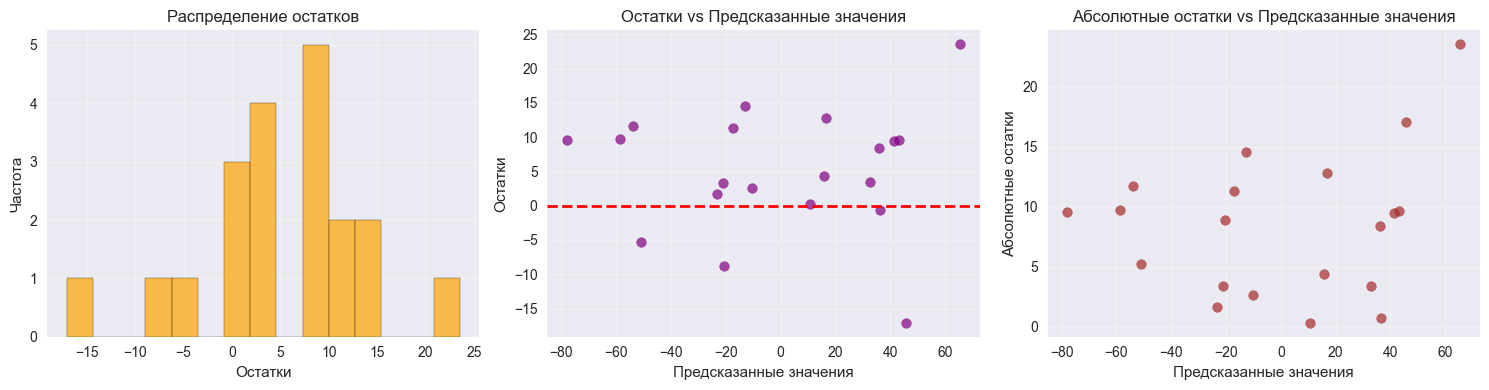

Анализ гомоскедастичности:
✓ Гомоскедастичность: соблюдается (остатки имеют постоянную дисперсию)


In [8]:
# Анализ остатков
residuals = y_test - y_pred

plt.figure(figsize=(15, 4))

# График 1: Распределение остатков
plt.subplot(1, 3, 1)
plt.hist(residuals, bins=15, alpha=0.7, color='orange', edgecolor='black')
plt.title('Распределение остатков')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

# График 2: Остатки vs Предсказанные значения
plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Остатки vs Предсказанные значения')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.grid(True, alpha=0.3)

# График 3: Проверка гомоскедастичности
plt.subplot(1, 3, 3)
plt.scatter(y_pred, np.abs(residuals), alpha=0.7, color='brown')
plt.title('Абсолютные остатки vs Предсказанные значения')
plt.xlabel('Предсказанные значения')
plt.ylabel('Абсолютные остатки')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ гомоскедастичности
print("Анализ гомоскедастичности:")
if np.std(residuals) < 0.5 * np.std(y_test):
    print("✓ Гомоскедастичность: соблюдается (остатки имеют постоянную дисперсию)")
else:
    print("⚠ Возможная гетероскедастичность: дисперсия остатков может меняться")

In [9]:
# Интерпретация результатов
print("\n" + "="*50)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"1. Уравнение регрессии: y = {model.intercept_:.4f} + {model.coef_[0]:.4f} * X")
print(f"2. R² = {r2:.4f} - модель объясняет {r2*100:.2f}% дисперсии зависимой переменной")
print(f"3. Средняя ошибка прогноза (RMSE): {rmse:.4f}")
print(f"4. Средняя абсолютная ошибка (MAE): {mae:.4f}")

# Оценка качества модели
if r2 > 0.8:
    quality = "ОТЛИЧНОЕ"
elif r2 > 0.6:
    quality = "ХОРОШЕЕ"
elif r2 > 0.4:
    quality = "УДОВЛЕТВОРИТЕЛЬНОЕ"
else:
    quality = "НИЗКОЕ"

print(f"5. Качество модели: {quality}")
print(f"6. При увеличении X на 1 единицу, Y изменяется на {model.coef_[0]:.4f}")


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Уравнение регрессии: y = 0.0992 + 44.2442 * X
2. R² = 0.9374 - модель объясняет 93.74% дисперсии зависимой переменной
3. Средняя ошибка прогноза (RMSE): 10.2079
4. Средняя абсолютная ошибка (MAE): 8.4167
5. Качество модели: ОТЛИЧНОЕ
6. При увеличении X на 1 единицу, Y изменяется на 44.2442
